In [1]:
# Standard imports
import polars as pl
import numpy as np
from pathlib import Path

import joblib

# Scikit-learn (baseline model and preprocessing)
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import log_loss, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Matplotlib/Seaborn styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["figure.dpi"] = 100

# Configuration
from IPython.display import display

# Polars display settings
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(15)

# Paths to data
TRAIN_PATH = Path("../data/interim/train_split.parquet")
VAL_PATH = Path("../data/interim/val_split.parquet")

# Verify files exist
print(f"Polars version: {pl.__version__}")
print(f"Train file exists: {TRAIN_PATH.exists()}")
print(f"Validation file exists: {VAL_PATH.exists()}")

Polars version: 1.39.3
Train file exists: True
Validation file exists: True


## Feature engineering

### Time features

In [2]:
# Load train and val lazy frames
train_lazy = pl.scan_parquet(TRAIN_PATH)
val_lazy = pl.scan_parquet(VAL_PATH)

# Function to add time features
def add_time_features(df):
    """Extract hour_of_day, day_of_week, and is_weekend from 'hour' column.

    Avazu hour format: YYMMDDHH (e.g., 14102100 = 2014-10-21 00:00).
    """
    return (
        df
        .with_columns(
            pl.col("hour").cast(pl.String).alias("hour_str")
        )
        .with_columns([
            pl.col("hour_str").str.slice(4,2).cast(pl.Int8).alias("day"),
            pl.col("hour_str").str.slice(6,2).cast(pl.Int8).alias("hour_of_day")
        ])
        .with_columns(
            # 21.10.2014 was a Tuesday (since Monday=0) --> day_of_week = 1
            # Day 21 = weekday 1, ..., day 27 = 0 (Monday)
            ((pl.col("day") - 21 + 1) % 7).alias("day_of_week")
        )
        .with_columns(
            # for weekend: Saturday=5, Sunday=6
            pl.col("day_of_week").is_in([5,6]).alias("is_weekend")
        )
        .drop("hour_str") # this columns is not needed anymore
    )

# Apply to both splits
train_lazy = add_time_features(train_lazy)
val_lazy = add_time_features(val_lazy)

# Quick check on train (show first few rows of new features) 
check = (
    train_lazy
    .select(["day","day_of_week","is_weekend"])
    # Sampling different days to verify time features correctly
    .unique()
    .sort("day")
    .collect()
)

# And check on val
check_val = (
    val_lazy
    .select(["day", "day_of_week", "is_weekend"])
    .unique()
    .sort("day")
    .collect()
)

display(check)
display(check_val)

day,day_of_week,is_weekend
i8,i8,bool
21,1,false
22,2,false
23,3,false
24,4,false
25,5,true
26,6,true
27,0,false
28,1,false


day,day_of_week,is_weekend
i8,i8,bool
29,2,false
30,3,false


## is_app flag (traffic type)

In [3]:
# Placeholder values from EDA
SITE_PLACEHOLDER_IN_APP_ID = "ecad2386"

# Function to add is_app flag
def add_is_app_flag(df):
    """Add is_app flag (boolean) based on app_id placeholder.
    
    If app_id equals the site placeholder, it's site traffic (False). Otherwise - app traffic (True).
    """
    return (
        df
        .with_columns(
            (pl.col("app_id") != SITE_PLACEHOLDER_IN_APP_ID).alias("is_app")
        )
    )

# Apply to both splits
train_lazy = add_is_app_flag(train_lazy)
val_lazy = add_is_app_flag(val_lazy)

# Quick check (CTR per is_app in train set)
check = (
    train_lazy
    .group_by("is_app")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("is_app")
    .collect()
)

display(check)

is_app,impressions,clicks,ctr
bool,u32,i64,f64
false,21135275,4233200,0.200291
true,11242146,1317640,0.117205


In [5]:
# See current columns in train
print(f"Current columns in train:\n {train_lazy.collect_schema().names()}")

Current columns in train:
 ['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'day', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_app']


In [6]:
# Sanity chech: distribution of new time features
sanity_check = (
    train_lazy
    .select([
        pl.col("day").min().alias("day_min"),
        pl.col("day").max().alias("day_max"),
        pl.col("hour_of_day").min().alias("hour_of_day_min"),
        pl.col("hour_of_day").max().alias("hour_of_day_max"),
        pl.col("day_of_week").min().alias("day_of_week_min"),
        pl.col("day_of_week").max().alias("day_of_week_max"),
        pl.col("is_weekend").sum().alias("weekend_rows"),
        pl.col("is_app").sum().alias("app_rows"),
        pl.len().alias("total"),
    ])
    .collect()
)

display(sanity_check)

day_min,day_max,hour_of_day_min,hour_of_day_max,day_of_week_min,day_of_week_max,weekend_rows,app_rows,total
i8,i8,i8,i8,i8,i8,u32,u32,u32
21,28,0,23,0,6,7199014,11242146,32377421


In [7]:
# Columns to drop (not useful for modeling)
DROP_COLS = ["id","day","hour"]

# Prepare features and target
def prepare_xy(df_lazy):
    """ Separate features from target, drop useless columns."""
    df = df_lazy.drop(DROP_COLS).collect()
    y = df["click"].to_numpy() # target (scikit-learn wants numpy arrays)
    X = df.drop("click") # all features (not converted to numpy array yet, first - encoding)
    return X, y

X_train, y_train = prepare_xy(train_lazy)
X_val, y_val = prepare_xy(val_lazy)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"\nTrain CTR (check): {y_train.mean():.4f}")
print(f"Val CTR (check): {y_val.mean():.4f}")    

X_train shape: (32377421, 25)
y_train shape: (32377421,)
X_val shape: (8051546, 25)
y_val shape: (8051546,)

Train CTR (check): 0.1714
Val CTR (check): 0.1632


## Feature encoding

In [8]:
# Columns grouped by encoding strategy

# One-hot encoding - low and medium cardinality (all categorical features with <10000 unique values)
ONEHOT_COLS = [
    # Low cardinality (<100 unique values)
    "C1","banner_pos","device_type","device_conn_type",
    "C15","C16","C18",
    "app_category","site_category",
    "hour_of_day","day_of_week",
    # Medium cardinality (100-10000 unique values)
    "C14", "C17","C19","C20","C21",
    "app_domain","app_id","site_domain","site_id","device_model",
    # Boolean feature (treat as categorical)
    "is_weekend", "is_app",
]

# Feature hashing - very high cardinality
# Bucket counts per column
HASH_BUCKETS = { # creating a dictionary of column names (key) and numbers of buckets for each (values) 
    "device_id": 10000, # 2.7M
    "device_ip": 10000, # 6.7M
}

total_hash_cols = sum(HASH_BUCKETS.values())
print(f"\nTotal hash output columns: {total_hash_cols:,}")

# Sanity check - verify all feature columns are accounted for
all_feature_cols = set(ONEHOT_COLS) | set(HASH_BUCKETS.keys())
actual_cols = set(X_train.columns)
missing = actual_cols - all_feature_cols # should be empty
extra = all_feature_cols - actual_cols # should be empty

print(f"Total one-hot columns: {len(ONEHOT_COLS)}")
print(f"Total hash columns: {len(HASH_BUCKETS)}")
print(f"Missing from strategy: {missing}")
print(f"Extra in strategy: {extra}")


Total hash output columns: 20,000
Total one-hot columns: 23
Total hash columns: 2
Missing from strategy: set()
Extra in strategy: set()


### One-hot encoding

In [9]:
# One-hot encoding for categorical columns (low cardinality)

ohe = OneHotEncoder(
    handle_unknown = "ignore", # val may have values not seen in train
    sparse_output = True, # return sparse matrix (memory efficient)
    drop = "first", # drop first category per column (avoiding multicollinearity)
    dtype = np.float32 # saving memory (default float64)
)

# Fit encoder (to learn all categories), then transform
print("Fitting (OneHotEncoder) and transforming train...")
X_train_ohe = ohe.fit_transform(X_train.select(ONEHOT_COLS).to_pandas())
print(f"Train one-hot shape: {X_train_ohe.shape}")

# Transform val (using already fitted list of values the encoder learned from train data for each column)
print("\nTransforming val...")
X_val_ohe = ohe.transform(X_val.select(ONEHOT_COLS).to_pandas())
print(f"Val one-hot shape: {X_val_ohe.shape}")

# Show category counts per column
print("\nCategories per column:")
for i in range(len(ONEHOT_COLS)):
    col = ONEHOT_COLS[i]
    cats = ohe.categories_[i]
    print(f"  {col:20s}: {len(cats):4d} unique ({len(cats)-1} after drop_first)")

joblib.dump(ohe, "../models/onehot_encoder.pkl")
print("OneHotEncoder saved.")

Fitting (OneHotEncoder) and transforming train...
Train one-hot shape: (32377421, 31549)

Transforming val...


C:\Users\jagod\miniconda3\envs\ctr-prediction\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [11, 12, 13, 15, 16, 17, 18, 19, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Val one-hot shape: (8051546, 31549)

Categories per column:
  C1                  :    7 unique (6 after drop_first)
  banner_pos          :    7 unique (6 after drop_first)
  device_type         :    5 unique (4 after drop_first)
  device_conn_type    :    4 unique (3 after drop_first)
  C15                 :    8 unique (7 after drop_first)
  C16                 :    9 unique (8 after drop_first)
  C18                 :    4 unique (3 after drop_first)
  app_category        :   36 unique (35 after drop_first)
  site_category       :   26 unique (25 after drop_first)
  hour_of_day         :   24 unique (23 after drop_first)
  day_of_week         :    7 unique (6 after drop_first)
  C14                 : 2252 unique (2251 after drop_first)
  C17                 :  372 unique (371 after drop_first)
  C19                 :   63 unique (62 after drop_first)
  C20                 :  172 unique (171 after drop_first)
  C21                 :   52 unique (51 after drop_first)
  app_domain    

['../models/onehot_encoder.pkl']

### Feature hashing

In [10]:
# Feature hashing for very high cardinality columns
from scipy.sparse import hstack, vstack # stack sparse matrices horizontally

def hash_columns(df, cols_with_buckets):
    """ Hash multiple columns to different number of buckets using FeatureHasher.

    Returns single scipy sparse matrix with all hashed columns stacked horizontally (shape (n_rows, n_buckets)).
    """
    hashed_parts = []
    
    for col, n_buckets in cols_with_buckets.items():
        # FeatureHasher expects iterable of dictionaries/lists/strings
        # Passing each value as a list with one string item
        values = df[col].cast(pl.String).to_list()
    
        hasher = FeatureHasher(
            n_features = n_buckets,
            input_type="string",
            alternate_sign=False # simpler interpratation with signs always positive
        )

        hashed = hasher.transform([[v] for v in values])
        hashed_parts.append(hashed)
        print(f" {col}: {n_buckets} buckets, shape: {hashed.shape}")

    # Hash - each value goes to its bucket (1 in that bucket, 0 elsewhere)
    return hstack(hashed_parts).tocsr() # stack all hashed columns horizontally (into one matrix)


# Hashing selected columns for train
print("Hashing train data...")
X_train_hashed = hash_columns(X_train, HASH_BUCKETS)
print(f"\nCombined train hashed shape: {X_train_hashed.shape}")

# Hash the same columns for val
print("Hashing val data...")
X_val_hashed = hash_columns(X_val, HASH_BUCKETS)
print(f"\nCombined val hashed shape: {X_val_hashed.shape}")

Hashing train data...
 device_id: 10000 buckets, shape: (32377421, 10000)
 device_ip: 10000 buckets, shape: (32377421, 10000)

Combined train hashed shape: (32377421, 20000)
Hashing val data...
 device_id: 10000 buckets, shape: (8051546, 10000)
 device_ip: 10000 buckets, shape: (8051546, 10000)

Combined val hashed shape: (8051546, 20000)


In [11]:
import gc

# Force Python to release memory (aka garbage collection)
gc.collect()

print("Cleanup done.")

# Check current memort usage
import psutil
mem = psutil.virtual_memory()
print(f"Available memory: {mem.available / 1e9:.2f} GB")
print(f"Used memory:      {mem.used / 1e9:.2f} GB")
print(f"Total memory:     {mem.total / 1e9:.2f} GB")

Cleanup done.
Available memory: 9.85 GB
Used memory:      24.17 GB
Total memory:     34.02 GB


### Combining all features

In [12]:
# Combine hashed and one-hot encoded features into single sparse matrix
X_train_final = hstack([X_train_ohe, X_train_hashed]).tocsr()
X_val_final = hstack([X_val_ohe, X_val_hashed]).tocsr()

print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_val shape: {X_val_final.shape}")

# Verify y arrays match
print(f"\ny_train shape: {y_train.shape}")
print(f"\ny_val shape: {y_val.shape}")

# Sanity check: number of rows should match between X and y
assert X_train_final.shape[0] == len(y_train), "Train rows mismatch!"
assert X_val_final.shape[0] == len(y_val), "Val rows mismatch!"
assert X_train_final.shape[1] == X_val_final.shape[1], "Column count mismatch!"

print("\nAll dimensions match.")

Final X_train shape: (32377421, 51549)
Final X_val shape: (8051546, 51549)

y_train shape: (32377421,)

y_val shape: (8051546,)

All dimensions match.


# Logistic regression with Stochastic Gradient Descent

In [14]:
import time
from sklearn.linear_model import SGDClassifier

# Stochastic Gradient Descent with log_loss as loss function
model_reg_log = SGDClassifier(
    loss = "log_loss", # logistic regression
    penalty = "l2", # L2 regularization - preventing overfitting, good for corelated features
    alpha = 0.0001, # regularization strenth (fitting to data)
    max_iter = 20, # number of epochs
    tol = 1e-4, # convergence tolerance
    n_jobs = -1, #  use all CPU cores (1 --> single-threaded)
    random_state = 42, # reproducibility
    verbose = 1, # show progress per epoch
    early_stopping = False
)

print("Training SGDClassifier on full train (32M rows)...")
print(f"Train shape: {X_train_final.shape}, {X_train_final.shape[1]:,} features")

start_time = time.time()
model_reg_log.fit(X_train_final, y_train)
elapsed = time.time() - start_time

print(f"\nTraining completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

joblib.dump(model_reg_log, "../models/sgdclassifier_reg_log.pkl")
print("SGDClassifier saved to ../models/sgdclassifier_reg_log.pkl")

Training SGDClassifier on full train (32M rows)...
Train shape: (32377421, 51549), 51,549 features
-- Epoch 1
Norm: 8.67, NNZs: 51549, Bias: -0.182664, T: 32377421, Avg. loss: 0.407559
Total training time: 16.33 seconds.
-- Epoch 2
Norm: 8.67, NNZs: 51549, Bias: -0.187473, T: 64754842, Avg. loss: 0.404335
Total training time: 32.97 seconds.
-- Epoch 3
Norm: 8.67, NNZs: 51549, Bias: -0.190311, T: 97132263, Avg. loss: 0.404278
Total training time: 49.32 seconds.
-- Epoch 4
Norm: 8.66, NNZs: 51549, Bias: -0.192287, T: 129509684, Avg. loss: 0.404253
Total training time: 67.01 seconds.
-- Epoch 5
Norm: 8.66, NNZs: 51549, Bias: -0.193910, T: 161887105, Avg. loss: 0.404235
Total training time: 84.73 seconds.
-- Epoch 6
Norm: 8.66, NNZs: 51549, Bias: -0.195126, T: 194264526, Avg. loss: 0.404230
Total training time: 102.33 seconds.
-- Epoch 7
Norm: 8.66, NNZs: 51549, Bias: -0.196168, T: 226641947, Avg. loss: 0.404225
Total training time: 118.20 seconds.
Convergence after 7 epochs took 118.20 se

### Evaluation

In [15]:
# Predict probabilities on val
print(f"Predicting on val...")
y_val_pred_proba = model_reg_log.predict_proba(X_val_final)[:, 1] # we want to get probability for class 1

# Check predictions should be in [0,1]
print(f"Prediction range: [{y_val_pred_proba.min():.4f},{y_val_pred_proba.max():.4f}]")
print(f"Mean prediction: {y_val_pred_proba.mean():.4f}")
print(f"Val CTR (actual): {y_val.mean():.4f}")

Predicting on val...
Prediction range: [0.0078,0.8184]
Mean prediction: 0.1712
Val CTR (actual): 0.1632


- 0.78% as minimum (model can tell where there will almost certainly not be a click)
- 81.84% as maximum (model can tell when the click probability is very high)
- 0.17 as mean --> matches the CTR for the training data (model remembers the mean from the training?)
- predicted CTR slightly higher than the actual one (+0.8 p.p. - the same as data drift between train and val)

Main issue: model recreates training stats for "new" data. 

### Metrics

In [16]:
# Baseline - trivial model predicting constant mean CTR
baseline_pred = np.full(len(y_val), y_train.mean())

# Metrics
log_loss_model = log_loss(y_val, y_val_pred_proba)
log_loss_baseline = log_loss(y_val, baseline_pred)
auc_model = roc_auc_score(y_val, y_val_pred_proba)
auc_baseline = 0.5 # AUC = 0.5 for trivial model by definition

# Display
print("BASELINE (constant prediction):")
print(f"  Log loss: {log_loss_baseline:.4f}")
print(f"  AUC: {auc_baseline:.4f}")

print("\nMODEL (logistic regression):")
print(f"  Log loss: {log_loss_model:.4f}")
print(f"  AUC: {auc_model:.4f}")

print("\nIMPROVEMENT:")
print(f"  Log loss reduction: {log_loss_baseline - log_loss_model:.4f} ({(log_loss_baseline - log_loss_model) / log_loss_baseline * 100:.2f}%)")
print(f"  AUC gain: {auc_model - auc_baseline:.4f}")

BASELINE (constant prediction):
  Log loss: 0.4452
  AUC: 0.5000

MODEL (logistic regression):
  Log loss: 0.3970
  AUC: 0.7321

IMPROVEMENT:
  Log loss reduction: 0.0482 (10.83%)
  AUC gain: 0.2321


#### ROC curve

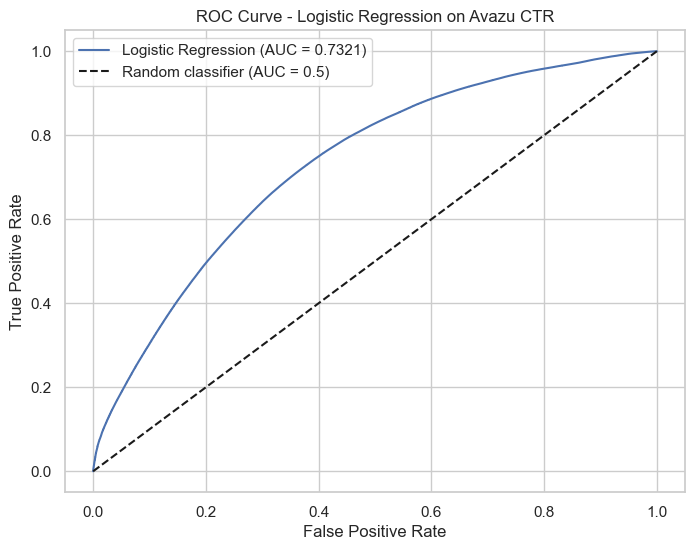

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC = {auc_model:.4})")
plt.plot([0,1], [0,1], "k--", label="Random classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression on Avazu CTR")
plt.legend()
plt.grid(True)
plt.show()

#### Reliability diagram

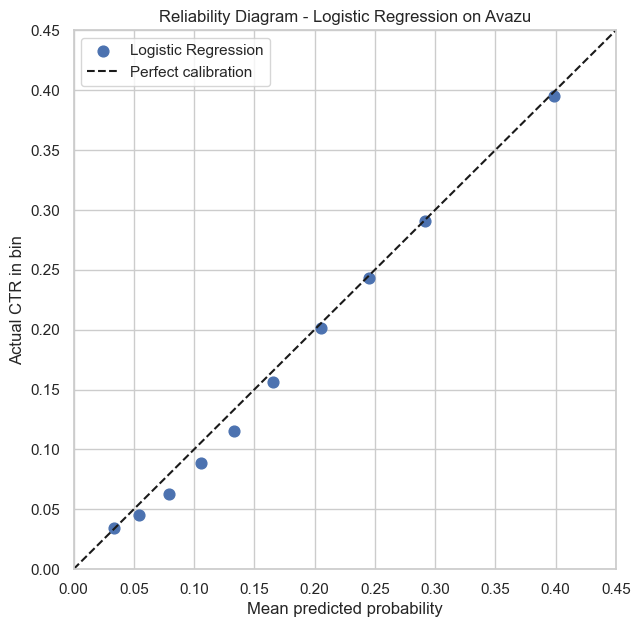


Calibration table:
  Bin 1: predicted 0.034, actual 0.034
  Bin 2: predicted 0.054, actual 0.046
  Bin 3: predicted 0.079, actual 0.063
  Bin 4: predicted 0.105, actual 0.088
  Bin 5: predicted 0.133, actual 0.115
  Bin 6: predicted 0.165, actual 0.157
  Bin 7: predicted 0.205, actual 0.202
  Bin 8: predicted 0.245, actual 0.243
  Bin 9: predicted 0.291, actual 0.290
  Bin 10: predicted 0.399, actual 0.395


In [18]:
from sklearn.calibration import calibration_curve

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_pred_proba,
    n_bins=10,
    strategy="quantile" # equal-size bins (not equal value ranges)
)

# Plot
plt.figure(figsize=(7, 7))
plt.scatter(prob_pred, prob_true, s=60, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual CTR in bin")
plt.title("Reliability Diagram - Logistic Regression on Avazu")
plt.legend()
plt.grid(True)
plt.xlim(0, 0.45)  # zoom in - predictions don't go above 0.4 in most bins
plt.ylim(0, 0.45)
plt.show()

# Print values for clarity
print("\nCalibration table:")
for i in range(len(prob_pred)):
    print(f"  Bin {i+1}: predicted {prob_pred[i]:.3f}, actual {prob_true[i]:.3f}")

Model slightly overestimates predictions at middle range (0.05-0.17), but almost perfectly works at extreme (edge) predictions. Generally works quite well.

### Feature importance 

In [20]:
# Get feature names from encoders
ohe_feature_names = ohe.get_feature_names_out(ONEHOT_COLS).tolist()

# Hashed features don't have meaningful names (just index them)
hash_feature_names = []
for col, n_buckets in HASH_BUCKETS.items():
    for i in range(n_buckets):
        hash_feature_names.append(f"hash_{col}_{i}")

# Combine in the same order as X_train_final
all_feature_names = ohe_feature_names + hash_feature_names

print(f"Total feature names: {len(all_feature_names):,}")
print(f"Model coefficients: {model_reg_log.coef_.shape:}") # shape of the weight matrix of the model
print(f"\nSamples feature names:")
print(f"  First 5: {all_feature_names[:5]}")
print(f"  Last 5: {all_feature_names[-5:]}")

Total feature names: 51,549
Model coefficients: (1, 51549)

Samples feature names:
  First 5: ['C1_1002', 'C1_1005', 'C1_1007', 'C1_1008', 'C1_1010']
  Last 5: ['hash_device_ip_9995', 'hash_device_ip_9996', 'hash_device_ip_9997', 'hash_device_ip_9998', 'hash_device_ip_9999']


In [21]:
# Create a DataFrame with feature names and coefficients
feature_importance = pl.DataFrame({
    "feature": all_feature_names,
    "coefficient": model_reg_log.coef_[0],
    "abs_coefficient": np.abs(model_reg_log.coef_[0]) 
})

# Top 20 features by absolute importance - decided by weight values
top_features = (
    feature_importance
    .sort("abs_coefficient", descending=True)
    .head(20)
)

print("Top 20 most important features:")
display(top_features)

Top 20 most important features:


feature,coefficient,abs_coefficient
str,f64,f64
"""device_model_cf28826a""",1.246964,1.246964
"""site_id_763a42b5""",1.04239,1.04239
"""app_id_95827a92""",0.951069,0.951069
"""site_id_84c7ba46""",0.901751,0.901751
"""app_id_9c13b419""",0.865976,0.865976
"""site_domain_d262cf1e""",-0.8229,0.8229
"""app_id_1779deee""",-0.806976,0.806976
"""app_id_da90aa44""",0.749431,0.749431
"""app_id_a5184c22""",0.728889,0.728889


- high-cardinality features dominate
- app_id=ecad2386 (placeholder for site traffic) --> negative value of coefficient - lower CTR predicted for site traffic
- device_id and device_ip not in top20 (too scattered signal? or not as valuable features as expected)

In [22]:
# Count hashing features in top N
for top_n in [20, 50, 100, 500, 1000]:
    top_features_n = (
        feature_importance
        .sort("abs_coefficient", descending=True)
        .head(top_n)
    )

    hash_count = top_features_n.filter(
        pl.col("feature").str.starts_with("hash_")
    ).height

    print(f"Top {top_n}: {hash_count} hashing features ({hash_count/top_n*100:.1f}%)")

Top 20: 0 hashing features (0.0%)
Top 50: 2 hashing features (4.0%)
Top 100: 2 hashing features (2.0%)
Top 500: 11 hashing features (2.2%)
Top 1000: 23 hashing features (2.3%)


Low impact on the model, despite being 39% of the whole matrix (20k/51.5k).

Possible reasons:
- collisions scattered the signal?
- other agregate features already consist that information (so some hashed features might be redundant)
- weakness of logistic regression (since it is a linear model)?

### Weight distribution

In [23]:
# Distribution of coefficient magnitudes
abs_coefs = np.abs(model_reg_log.coef_[0]) # absolute values of all weigths

# Threshold analysis
thresholds = [0.001, 0.01, 0.1, 0.5, 1.0]
total = len(abs_coefs)

print(f"Total features: {total:,}")
print(f"\nFeatures above threshold:")
for t in thresholds:
    count = (abs_coefs > t).sum() # how many exceeds the threshold
    print(f" |coeff| > {t}: {count:,} features ({count/total*100:.1f}%)")

Total features: 51,549

Features above threshold:
 |coeff| > 0.001: 30,125 features (58.4%)
 |coeff| > 0.01: 8,396 features (16.3%)
 |coeff| > 0.1: 959 features (1.9%)
 |coeff| > 0.5: 50 features (0.1%)
 |coeff| > 1.0: 2 features (0.0%)


- for 41.6% of features the weights are virtually 0 (< 0.001) - almost useless
- for 16.3% weights > 0.01 - somewhat useful
- 1.9% > 0.1 - strong features
- 0.1% > 0.5 - very strong signals
- only 2 features with weights > 1 (based on top20 above, 1 device_model and 1 site_id) - very very strong signals

#### Conclusions
- high redundancy - 58% of features contributing anything, only 2% really important
- might be reasonable to exclude the weakest features --> less noise and dimensionality reduction